In [7]:
import sys
sys.path.insert(0, "..")

from sklearn.preprocessing import StandardScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import rioxarray as rxr
import numpy as np
import cmocean
import math
import rasterio
from rasterio.sample import sample_gen
from rasterio.features import rasterize
from rasterio.enums import Resampling

from plotnine import *

import dask.dataframe as dd

import xarray as xr
import pandas as pd
import geopandas as gpd
import re
from tqdm.notebook import tqdm

# Analysis


1. Spatiotemporal variation
   1. System-wide patterns
   2. Bank-by-bank
   3. Sediment budget
      1. System-wide
      2. Bank-by-bank

2. Seagrass-bathymetry change relationship

In [47]:
from config import *

# -- Catalog --------------------------------------------------------------------------------------------
CATALOG                 = load_catalog()
INPUT_ASSETS            = {
                            "pred" : "bathy-pred",
                            "pred_int" : "std",
                            "stack" : "stack",
                            "sg_percov" : "seagrass-percov"
                        }

# ---  ---
STACK_COLS = ["idx", "pred", "std", "img_id", "date", "nd_B_R", "log_R", "nd_G_R", "nd_B_Y", "log_Y", "nd_G_Y", "sg_percov", "sg_species", "sensor"]

# --- Algorithm Parameters ---
N_SAMPLES = 500

# --- Plotting ---
BANK_LABELS = {
    "amity": "Amity",
    "chain": "Chain",
    "maroom": "Maroom",
    "moreton": "Moreton",
    "wanga": "Wanga-Wallen",
    "sth_pass" : "Reeder"
}

FEATURE_LABELS = {
    "pred":   "Pred. elev.",
    "nd_B_R": "ND(B,R)",
    "log_R":  "log(R)",
    "nd_G_R": "ND(G,R)",
    "nd_B_Y": "ND(B,Y)",
    "log_Y":  "log(Y)",
    "nd_G_Y": "ND(G,Y)",
}

cm = 1/2.54

In [9]:
# --- catalofg query ---
preds = sorted(
    [item for child in ("wv2-imagery", "sd8-imagery")
           for item in CATALOG.get_child(child).get_items()
           if INPUT_ASSETS["pred"] in item.assets],
    key=lambda item: item.datetime
)

# --- metadata ---
dates = [p.datetime for p in preds]
years = [p.datetime.year for p in preds]

YEAR_LABELS = {p.id: str(p.datetime.year) for p in preds}
sensors = np.array([0 if "wv2-imagery" in p.collection_id else 1 for p in preds])
t_all = np.array([p.datetime.year + (p.datetime.timetuple().tm_yday - 1) / 365.25 for p in preds])

wv2_idx, sd8_idx = np.where(sensors == 0)[0], np.where(sensors == 1)[0]
t_e1, t_e2 = t_all[wv2_idx], t_all[sd8_idx]

# --- raster load ---
def _load(item, key):
    return (rxr.open_rasterio(item.assets[key].href, masked=True).squeeze("band", drop=True).values.astype(np.float32))

pred_arrays, pred_int_arrays = zip(*[(_load(item, INPUT_ASSETS["pred"]), _load(item, INPUT_ASSETS["pred_int"])) for item in preds])

# --- stack ---
stack_pred = np.stack(pred_arrays, axis=0)
stack_int = np.stack(pred_int_arrays, axis=0)

# --- bank data ---
banks = gpd.read_file("C:/Users/samla/study/25-SEM3.ENVM7133/ENVM7133/data/banks")
banks = banks.to_crs(crs = "EPSG:32756")
bank_id_to_name = {i: n for i, n in enumerate(banks["bank"])}

# --- persist data ---
persist = rxr.open_rasterio("C:/Users/samla/study/25-SEM3.ENVM7133/ENVM7133/data/seagrass_maps/seagrass_persistence_overall.tiff")


In [4]:
# --- Get metadata ---
with rasterio.open(preds[0].assets[INPUT_ASSETS["pred"]].href) as src:
    crs = src.crs
    shape = src.shape
    H, W = shape[0], shape[1]
    transform = src.transform

# --- spatial index ---
n_px = shape[0] * shape[1]
rows, cols = np.unravel_index(np.arange(n_px), shape)
xs, ys = rasterio.transform.xy(transform, rows, cols)

extent = [
    transform.c,
    transform.c + transform.a * W,
    transform.f + transform.e * H,
    transform.f
]

In [5]:
print(crs)

EPSG:32756


In [6]:
# --- bank lookup ---
bank_raster = rasterize(
    [(geom, i) for i, geom in enumerate(banks.geometry)],
    out_shape = shape, transform = transform, fill = -1, dtype = np.int16
)

# --- persist lookup ---
persist_reproj = persist.rio.reproject(crs, shape = shape, transform = transform, resampling = Resampling.nearest).squeeze()

persist_flat = persist_reproj.values.ravel().astype(np.float32)
del persist_reproj

# Decadal elevation change (DoD, minLoD)
- Brasington et al, 2003
  - pg 313, delta u, u_crit
- Lane et al, 2003
  - eq 7
  - "The estimates of volumes of change, despite being downgraded as compared with traditional cross-section survey in terms of point precision, produced more reliable erosion and deposition estimates as a result of the large improvement in spatial density that synoptic methods provide."
    - pred_int is lower precision than sonar but the spatial density compensates
- Wheaton et al, 2010

In [10]:
pred_e1, pred_e2 = stack_pred[wv2_idx].mean(axis=0).ravel(), stack_pred[sd8_idx].mean(axis=0).ravel()
pred_int_e1, pred_int_e2 = stack_int[wv2_idx].mean(axis=0).ravel(), stack_int[sd8_idx].mean(axis=0).ravel()

# --- DoD and minLoD ---
dod = pred_e2 - pred_e1
minlod = np.sqrt(pred_int_e1**2 + pred_int_e2**2)
delta_thresh = np.where(np.abs(dod) > minlod, dod, np.nan)

df = pd.DataFrame({
    "idx": np.arange(n_px, dtype=np.int32),
    "row": rows,
    "col": cols,
    "x": np.array(xs, dtype=np.float32),
    "y": np.array(ys, dtype=np.float32),
    "bank": pd.Series(bank_raster.ravel()).map(bank_id_to_name),
    "persist": persist_flat,
    "pred_e1": pred_e1,
    "pred_int_e1": pred_int_e1,
    "pred_e2": pred_e2,
    "pred_int_e2": pred_int_e2,
    "dod": dod,
    "minlod": minlod,
    "delta_thresh": delta_thresh,
    "delta_direction": np.where(np.isnan(delta_thresh), "below_lod", np.where(delta_thresh > 0, "positive", "negative"))
})

In [11]:
# Sensors and images
print(f"\nSensors: {sensors}")
print(f"WV2 idx: {wv2_idx}")
print(f"SD8 idx: {sd8_idx}")

# df stats
print(f"\nTotal pixels: {len(df):,}")
print(f"Valid pred_e1: {df['pred_e1'].notna().sum():,}")
print(f"Valid pred_e2: {df['pred_e2'].notna().sum():,}")
print(f"Valid both: {(df['pred_e1'].notna() & df['pred_e2'].notna()).sum():,}")

print("\nRestricting to valid...")
df = df[df["bank"].notna() & df["pred_e1"].notna() & df["pred_e2"].notna()]

print(f"Above minLoD: {df['delta_thresh'].notna().sum():,} ({df['delta_thresh'].notna().mean():.1%})")
print(f"Below minLoD: {df['delta_thresh'].isna().sum():,} ({df['delta_thresh'].isna().mean():.1%})")

sig = df[df["delta_thresh"].notna()]
below_lod = df[df["delta_thresh"].isna()]

print(f"Accretion: {(sig['delta_thresh'] > 0).sum():,} ({(sig['delta_thresh'] > 0).mean():.1%})")
print(f"Erosion: {(sig['delta_thresh'] < 0).sum():,} ({(sig['delta_thresh'] < 0).mean():.1%})")

display(df.groupby(["bank", "delta_direction"]).size().unstack(fill_value=0))


Sensors: [0 0 0 0 1 1 1 1]
WV2 idx: [0 1 2 3]
SD8 idx: [4 5 6 7]

Total pixels: 35,268,200
Valid pred_e1: 12,473,571
Valid pred_e2: 12,716,469
Valid both: 12,462,228

Restricting to valid...
Above minLoD: 3,457,982 (30.4%)
Below minLoD: 7,922,546 (69.6%)
Accretion: 3,430,220 (99.2%)
Erosion: 27,762 (0.8%)


delta_direction,below_lod,negative,positive
bank,,,
amity,2356627,6589,805114
chain,295687,0,31828
maroom,1609100,0,95018
moreton,2792470,9,2169468
sth_pass,394613,12505,206250
wanga,474049,8659,122542


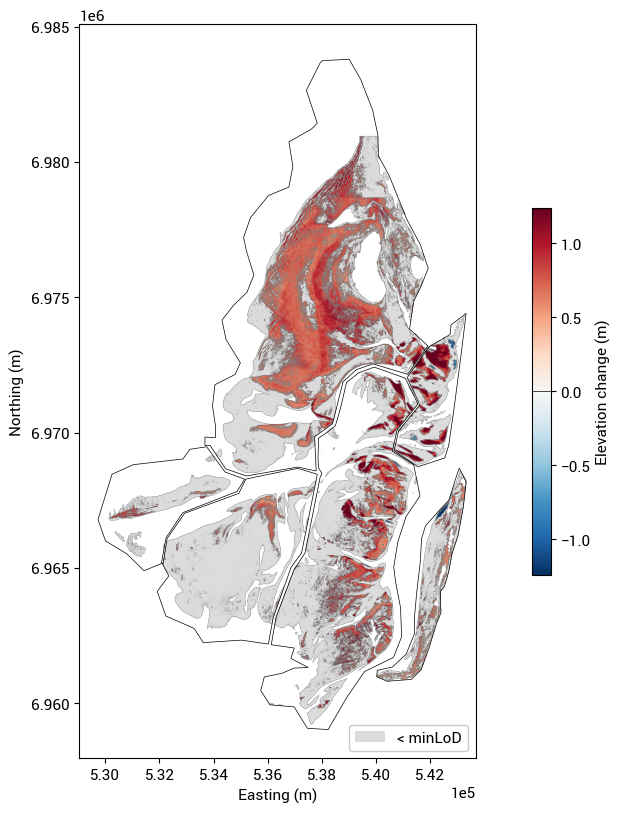

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# --- Reconstruct spatial grids from df ---
delta_grid = np.full((H, W), np.nan)
below_lod_grid = np.full((H, W), np.nan)

delta_grid[df["row"].values, df["col"].values] = df["delta_thresh"].values
below_lod_grid[df.loc[df["delta_thresh"].isna(), "row"].values, df.loc[df["delta_thresh"].isna(), "col"].values] = 1

# --- Symmetric colorbar limits ---
vmax = np.nanpercentile(np.abs(delta_grid), 95)
vmin = -vmax

# --- Plot ---
fig, ax = plt.subplots(figsize=(29.7*cm, 21*cm))

# --- below lod = grey ---
ax.imshow(below_lod_grid, cmap=mcolors.ListedColormap(["gainsboro"]), extent=extent, origin="upper", zorder=1)

# --- continuous divergin for sig change ---
im = ax.imshow(delta_grid, cmap="RdBu_r", vmin=vmin, vmax=vmax, extent=extent, origin="upper", zorder=2)

# --- banks ---
banks.boundary.plot(ax=ax, color="black", linewidth=0.5, zorder=3)

# --- cbar ---
cbar = plt.colorbar(im, ax=ax, shrink=0.5)
cbar.set_label("Elevation change (m)", fontsize=11)
cbar.ax.axhline(0, color="black", linewidth=0.5)

# --- legend ---
ax.legend(handles=[Patch(facecolor="gainsboro", label="< minLoD")], loc="lower right", framealpha=1)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
plt.tight_layout()
plt.savefig("../out/figs/dod_continuous.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\samla\AppData\Local\Temp\ipykernel_35716\356850319.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
c:\Users\samla\.conda\envs\geospat\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.26771653543307 x 3.149606299212598 in image.
c:\Users\samla\.conda\envs\geospat\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: ../out/figs/dod_violin.png


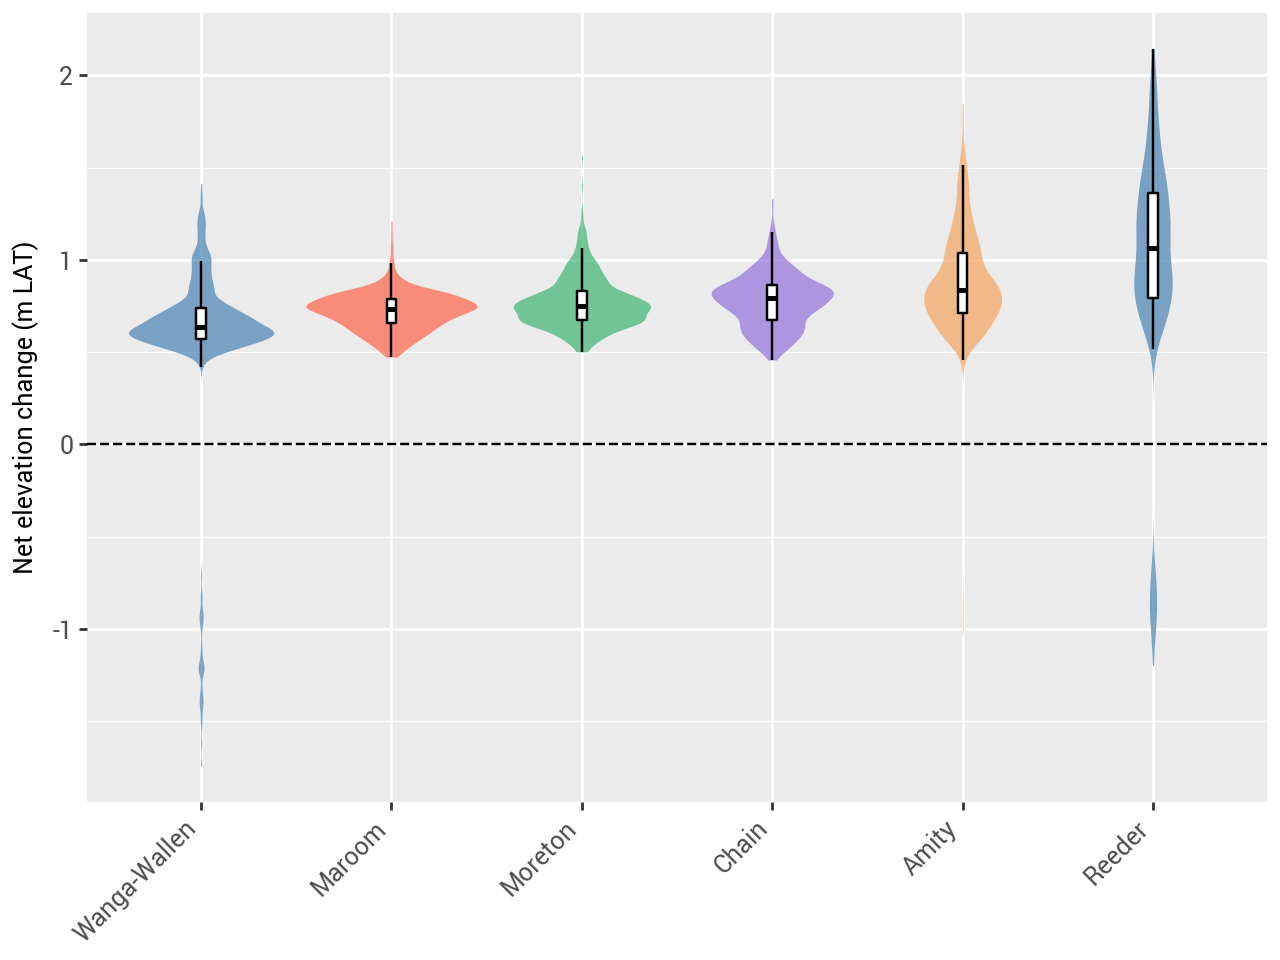

In [63]:
# --- subset for vis ---
sub = (sig.groupby("bank", group_keys=False)
        .apply(lambda x: x.sample(n=min(N_SAMPLES, len(x)), random_state=SEED))
        .reset_index(drop=True))

bank_order = (sub.groupby("bank")["delta_thresh"].median().sort_values().index.tolist())
sub["bank"] = pd.Categorical(sub["bank"], categories=bank_order, ordered=True)

# --- labels ---
sub["bank_label"] = sub["bank"].map(BANK_LABELS)
bank_label_order = [BANK_LABELS[b] for b in bank_order]
sub["bank_label"] = pd.Categorical(sub["bank_label"], categories=bank_label_order, ordered=True)

# --- plot ---
p = (
    ggplot(sub, aes(x="bank_label", y="delta_thresh", fill="bank"))
    + geom_violin(trim=True, show_legend=False, alpha=0.7, color=None)
    + geom_boxplot(width=0.05, outlier_alpha=0, show_legend=False, fill="white", color="black")
    + geom_hline(yintercept=0, linetype="dashed", color="black", size=0.5)
    + scale_fill_manual(values={
        bank: color for bank, color in zip(bank_order, 
        ["steelblue", "tomato", "mediumseagreen", "mediumpurple", "sandybrown", "steelblue"])
    })
    + labs(
        title="",
        x="",
        y="Net elevation change (m LAT)"
    )
    + theme(
        text=element_text(size=9, family="Roboto"),
        plot_title=element_text(size=9, family="Roboto"),
        axis_text=element_text(size=9, family="Roboto"),
        axis_text_x=element_text(size=9, family="Roboto", rotation=45, hjust=1),
        axis_title=element_text(size=9, family="Roboto"),
)
)

p.save("../out/figs/dod_violin.png", dpi=300, width= 15.92*cm, height=8*cm)
p

In [14]:
from scipy import stats
from itertools import combinations

grps = {b: sig.loc[sig["bank"] == b, "delta_thresh"].dropna() for b in bank_order}

# --- Between banks (Kruskal-Wallis) ---
h, p_kw = stats.kruskal(*grps.values())
n_total = sum(len(g) for g in grps.values())
eta2 = (h - len(grps) + 1) / (n_total - len(grps))
print(f"H = {h:.3f}, p = {p_kw:.4f}, η² = {eta2:.4f}")

# --- Pairwise Mann-Whitney ---
mwu_dod = []
for b1, b2 in combinations(bank_order, 2):
    v1 = sig[sig["bank"] == b1]["delta_thresh"].dropna()
    v2 = sig[sig["bank"] == b2]["delta_thresh"].dropna()
    stat, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
    r_rb = 1 - (2 * stat) / (len(v1) * len(v2))
    mwu_dod.append({
        "bank_1": b1,
        "bank_2": b2,
        "stat": round(stat, 1),
        "p": round(p, 4),
        "r_rb": round(r_rb, 3)
    })

mwu_dod = pd.DataFrame(mwu_dod)
display(mwu_dod)

H = 452289.475, p = 0.0000, η² = 0.1308


,bank_1,bank_2,stat,p,r_rb
0,wanga,maroom,3.750736e+09,0.0,0.398
1,wanga,moreton,7.230048e+10,0.0,0.492
2,wanga,chain,1.136849e+09,0.0,0.456
3,wanga,amity,2.060316e+10,0.0,0.613
4,wanga,sth_pass,4.050095e+09,0.0,0.718
5,maroom,moreton,8.920131e+10,0.0,0.135
6,maroom,chain,1.195638e+09,0.0,0.209
7,maroom,amity,2.165000e+10,0.0,0.439
8,maroom,sth_pass,3.688041e+09,0.0,0.645
9,moreton,chain,3.224687e+10,0.0,0.066


In [15]:
mean_rrb = (
    mwu_dod
    .melt(id_vars="r_rb", value_vars=["bank_1", "bank_2"], value_name="bank")
    .groupby("bank")["r_rb"].mean()
    .sort_values(ascending=False)
    .rename("mean_r_rb")
    .to_frame()
)

display(mean_rrb.round(3))

,mean_r_rb
bank,
sth_pass,0.563
wanga,0.535
amity,0.398
maroom,0.365
moreton,0.320
chain,0.312


In [16]:
stats_dod_bank = (sig.groupby("bank")["delta_thresh"]
    .agg(count="count", mean="mean",
         q25 = lambda x: x.quantile(.25),
         median = "median",
         q75 = lambda x: x.quantile(.75),
         iqr = lambda x: x.quantile(.75) - x.quantile(.25),
         min = "min", max="max")
    .round(3))
display(stats_dod_bank)

stats_dod_total = sig["delta_thresh"].agg(
    count="count", mean="mean",
    q25 = lambda x: x.quantile(.25),
    median = "median",
    q75 = lambda x: x.quantile(.75),
    iqr = lambda x: x.quantile(.75) - x.quantile(.25),
    min = "min", max="max"
).rename("Total").to_frame().T.round(3)
stats_dod_total.index.name = "bank"

display(stats_dod_total)


,count,mean,q25,median,q75,iqr,min,max
bank,,,,,,,,
amity,811703,0.891,0.722,0.858,1.049,0.327,-1.633,2.232
chain,31828,0.779,0.665,0.789,0.872,0.207,0.419,1.406
maroom,95018,0.732,0.661,0.735,0.800,0.140,0.431,1.502
moreton,2169477,0.769,0.677,0.750,0.841,0.164,-0.994,1.934
sth_pass,218755,1.031,0.818,1.061,1.362,0.544,-1.599,2.292
wanga,131201,0.558,0.565,0.627,0.712,0.147,-1.933,1.970


,count,mean,q25,median,q75,iqr,min,max
bank,,,,,,,,
Total,3457982.0,0.806,0.68,0.771,0.895,0.214,-1.933,2.292


- 30.2% of pixels exceeded minLoD, only these interpreted as real change
- 69.8% below minLoD, change is indistinguishable from model uncertainty

- 99.2% positive elevation change, 0.8% negative elevation change = overwhelming positive change signal
- median positive elevation change = +0.771m between epochs, IQR = 0.681-0.895m
- Large signal relative to minLoD (median = 0.733); change is real but only just exceeding uncertainty at the median

- Mean minLoD = 0.776m vs mean delta_thresh = 0.807m; the signal is only marginally above the noise threshold on average
- This means 30.2% figure is conservative; the real extent of change is likely greater but possibly masked by prediction uncertainty



# Annual elevation trends

In [17]:
from scipy.stats import norm as sp_norm

def mk_ts(X, t):
    n_px, n_t = X.shape
    ii, jj = np.triu_indices(n_t, k = 1)
    diff = X[:, jj] - X[:, ii]
    n_obs = (~np.isnan(X)).sum(axis=1)

    S = np.nansum(np.sign(diff), axis=1)
    var_S = np.where(n_obs > 2, n_obs * (n_obs - 1) * (2 * n_obs + 5) / 18, np.nan)

    Z = np.where(S > 0, (S - 1) / np.sqrt(var_S), np.where(S < 0, (S + 1) / np.sqrt(var_S), 0.0))

    p = 2 * (1 - sp_norm.cdf(np.abs(Z)))
    tau = S / (ii.size)

    dt = t[jj] - t[ii]
    pair_slope = np.where(~np.isnan(diff), diff / dt, np.nan)
    slope = np.nanmedian(pair_slope, axis=1)

    mask = n_obs < 3
    slope[mask] = np.nan
    p[mask] = np.nan
    tau[mask] = np.nan

    return slope.astype(np.float32), p.astype(np.float32), tau.astype(np.float32)

idx = df["idx"].values
full_e1 = stack_pred[wv2_idx].reshape(len(wv2_idx), -1)[:, idx].T
full_e2 = stack_pred[sd8_idx].reshape(len(sd8_idx), -1)[:, idx].T

slope_e1, p_e1, tau_e1 = mk_ts(full_e1, t_e1)
slope_e2, p_e2, tau_e2 = mk_ts(full_e2, t_e2)

df = df.assign(
    ts_slope_e1 = slope_e1,
    mk_p_e1 = p_e1,
    mk_tau_e1 = tau_e1,
    ts_slope_e2 = slope_e2,
    mk_p_e2 = p_e2,
    mk_tau_e2 = tau_e2
)

In [18]:
from scipy import stats

for epoch, slope_col, p_col in [
    ("2011-2015", "ts_slope_e1", "mk_p_e1"),
    ("2022-2025", "ts_slope_e2", "mk_p_e2"),
]:
    grps = {b: g[slope_col].dropna() for b, g in df.groupby("bank")}

    # --- desc stats ---
    stats_mk = pd.DataFrame({
        b: {"n": len(v), "median": v.median(),
            "q25": v.quantile(.25), "q75": v.quantile(.75),
            "pct_neg": (v < 0).mean(), "pct_pos": (v > 0).mean(),
            "pct_sig": (df.loc[df["bank"] == b, p_col] < 0.05).mean()}
        for b, v in grps.items()
    }).T.round(3)

    # --- wilcoxon ---
    def _wilcoxon(bank, vals):
        stat, p = stats.wilcoxon(vals, alternative="less")
        n = len(vals)
        return {"p": round(p, 4), "r": round((2*stat)/(n*(n+1)/2) - 1, 3)}

    wilcoxon_mk = pd.DataFrame([_wilcoxon(b, v) for b, v in grps.items()])

    # --- Kruskal Wallis ---
    h, p_kw = stats.kruskal(*grps.values())
    n_total = sum(len(v) for v in grps.values())
    eta2 = (h - len(grps) + 1) / (n_total - len(grps))
    kw_mk = pd.DataFrame([{"epoch": epoch, "H": round(h, 3), "p": round(p_kw, 4), "eta2": round(eta2, 4)}]).set_index("epoch")
    
    # --- pairwise mwu ---
    def _mwu(bank_1, bank_2):
        v1, v2 = grps[bank_1], grps[bank_2]
        stat, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
        return {"bank_1": bank_1, "bank_2": bank_2, "p": round(p, 4), "r_rb": round(1 - (2*stat)/(len(v1)*len(v2)), 3)}
    
    mwu_mk = pd.DataFrame([_mwu(b1, b2) for b1, b2 in combinations(grps, 2)])

    mean_rrb_mk = (
        mwu_mk
        .melt(id_vars="r_rb", value_vars=["bank_1", "bank_2"], value_name="bank")
        .groupby("bank")["r_rb"].mean()
        .sort_values(ascending=False)
        .rename("mean_r_rb")
        .to_frame()
    )

    display(stats_mk)
    display(wilcoxon_mk)
    display(kw_mk)
    display(mwu_mk)
    display(mean_rrb_mk)

,n,median,q25,q75,pct_neg,pct_pos,pct_sig
amity,3168330.0,-0.064,-0.143,-0.008,0.802,0.198,0.0
chain,327515.0,-0.015,-0.115,0.003,0.689,0.311,0.0
maroom,1704118.0,-0.012,-0.060,0.006,0.666,0.334,0.0
moreton,4961947.0,-0.103,-0.176,-0.012,0.802,0.198,0.0
sth_pass,613368.0,-0.058,-0.166,0.041,0.650,0.350,0.0
wanga,605250.0,-0.019,-0.098,0.053,0.567,0.433,0.0


,p,r
0,0.0,-0.779
1,0.0,-0.640
2,0.0,-0.502
3,0.0,-0.715
4,0.0,-0.416
5,0.0,-0.195


,H,p,eta2
epoch,,,
2011-2015,702705.997,0.0,0.0617


,bank_1,bank_2,p,r_rb
0,amity,chain,0.0,0.156
1,amity,maroom,0.0,0.312
2,amity,moreton,0.0,-0.111
3,amity,sth_pass,0.0,0.073
4,amity,wanga,0.0,0.297
5,chain,maroom,0.0,0.135
6,chain,moreton,0.0,-0.231
7,chain,sth_pass,0.0,-0.015
8,chain,wanga,0.0,0.194
9,maroom,moreton,0.0,-0.374


,mean_r_rb
bank,
wanga,0.2168
amity,0.1454
chain,0.0478
sth_pass,0.0456
maroom,0.0006
moreton,-0.0438


,n,median,q25,q75,pct_neg,pct_pos,pct_sig
amity,3168330.0,-0.027,-0.099,0.044,0.606,0.394,0.0
chain,327515.0,-0.038,-0.110,0.020,0.669,0.331,0.0
maroom,1704118.0,-0.021,-0.080,0.039,0.592,0.408,0.0
moreton,4961947.0,-0.035,-0.085,0.018,0.679,0.321,0.0
sth_pass,613368.0,-0.001,-0.110,0.098,0.502,0.498,0.0
wanga,605250.0,-0.053,-0.107,0.003,0.738,0.262,0.0


,p,r
0,0.0,-0.271
1,0.0,-0.496
2,0.0,-0.252
3,0.0,-0.439
4,0.0,-0.022
5,0.0,-0.569


,H,p,eta2
epoch,,,
2022-2025,90471.751,0.0,0.0079


,bank_1,bank_2,p,r_rb
0,amity,chain,0.0,-0.096
1,amity,maroom,0.0,0.042
2,amity,moreton,0.0,-0.034
3,amity,sth_pass,0.0,0.097
4,amity,wanga,0.0,-0.136
5,chain,maroom,0.0,0.147
6,chain,moreton,0.0,0.064
7,chain,sth_pass,0.0,0.182
8,chain,wanga,0.0,-0.047
9,maroom,moreton,0.0,-0.087


,mean_r_rb
bank,
sth_pass,0.0560
chain,0.0500
maroom,-0.0046
moreton,-0.0088
amity,-0.0254
wanga,-0.1424


In [19]:
sig_idx = sig["idx"].values
sig_e1 = stack_pred[wv2_idx].reshape(len(wv2_idx), -1)[:, sig_idx].T
sig_e2 = stack_pred[sd8_idx].reshape(len(sd8_idx), -1)[:, sig_idx].T

sig_slope_e1, sig_p_e1, sig_tau_e1 = mk_ts(sig_e1, t_e1)
sig_slope_e2, sig_p_e2, sig_tau_e2 = mk_ts(sig_e2, t_e2)

# Write results back to sig (not df) using new column names
sig = sig.assign(
    sig_ts_slope_e1 = sig_slope_e1,
    sig_mk_p_e1     = sig_p_e1,
    sig_mk_tau_e1   = sig_tau_e1,
    sig_ts_slope_e2 = sig_slope_e2,
    sig_mk_p_e2     = sig_p_e2,
    sig_mk_tau_e2   = sig_tau_e2
)

In [20]:
from scipy import stats
for epoch, slope_col, p_col in [
    ("2011-2015", "sig_ts_slope_e1", "sig_mk_p_e1"),
    ("2022-2025", "sig_ts_slope_e2", "sig_mk_p_e2"),
]:
    grps = {b: g[slope_col].dropna() for b, g in sig.groupby("bank")}
    # --- desc stats ---
    stats_mk_sig = pd.DataFrame({
        b: {"n": len(v), "median": v.median(),
            "q25": v.quantile(.25), "q75": v.quantile(.75),
            "pct_neg": (v < 0).mean(), "pct_pos": (v > 0).mean(),
            "pct_sig": (sig.loc[sig["bank"] == b, p_col] < 0.05).mean()}
        for b, v in grps.items()
    }).T.round(3)
    # --- wilcoxon ---
    def _wilcoxon(bank, vals):
        stat, p = stats.wilcoxon(vals, alternative="less")
        n = len(vals)
        return {"p": round(p, 4), "r": round((2*stat)/(n*(n+1)/2) - 1, 3)}
    wilcoxon_mk_sig = pd.DataFrame([_wilcoxon(b, v) for b, v in grps.items()])
    # --- Kruskal Wallis ---
    h, p_kw = stats.kruskal(*grps.values())
    n_total = sum(len(v) for v in grps.values())
    eta2 = (h - len(grps) + 1) / (n_total - len(grps))
    kw_mk_sig = pd.DataFrame([{"epoch": epoch, "H": round(h, 3), "p": round(p_kw, 4), "eta2": round(eta2, 4)}]).set_index("epoch")
    # --- pairwise mwu ---
    def _mwu(bank_1, bank_2):
        v1, v2 = grps[bank_1], grps[bank_2]
        stat, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
        return {"bank_1": bank_1, "bank_2": bank_2, "p": round(p, 4), "r_rb": round(1 - (2*stat)/(len(v1)*len(v2)), 3)}
    mwu_mk_sig = pd.DataFrame([_mwu(b1, b2) for b1, b2 in combinations(grps, 2)])
    mean_rrb_mk_sig = (
        mwu_mk_sig
        .melt(id_vars="r_rb", value_vars=["bank_1", "bank_2"], value_name="bank")
        .groupby("bank")["r_rb"].mean()
        .sort_values(ascending=False)
        .rename("mean_r_rb")
        .to_frame()
    )
    display(stats_mk_sig)
    display(wilcoxon_mk_sig)
    display(kw_mk_sig)
    display(mwu_mk_sig)
    display(mean_rrb_mk_sig)

,n,median,q25,q75,pct_neg,pct_pos,pct_sig
amity,811703.0,-0.088,-0.159,-0.022,0.824,0.176,0.0
chain,31828.0,-0.066,-0.152,-0.011,0.872,0.128,0.0
maroom,95018.0,-0.197,-0.225,-0.122,0.952,0.048,0.0
moreton,2169477.0,-0.151,-0.195,-0.061,0.881,0.119,0.0
sth_pass,218755.0,-0.022,-0.125,0.068,0.569,0.431,0.0
wanga,131201.0,-0.062,-0.122,0.013,0.706,0.294,0.0


,p,r
0,0.0,-0.789
1,0.0,-0.915
2,0.0,-0.989
3,0.0,-0.872
4,0.0,-0.199
5,0.0,-0.534


,H,p,eta2
epoch,,,
2011-2015,271631.738,0.0,0.0786


,bank_1,bank_2,p,r_rb
0,amity,chain,0.0,0.026
1,amity,maroom,0.0,-0.488
2,amity,moreton,0.0,-0.238
3,amity,sth_pass,0.0,0.280
4,amity,wanga,0.0,0.198
5,chain,maroom,0.0,-0.444
6,chain,moreton,0.0,-0.235
7,chain,sth_pass,0.0,0.290
8,chain,wanga,0.0,0.175
9,maroom,moreton,0.0,0.312


,mean_r_rb
bank,
sth_pass,0.2968
wanga,0.2646
moreton,0.1394
maroom,0.1260
chain,-0.0376
amity,-0.0444


,n,median,q25,q75,pct_neg,pct_pos,pct_sig
amity,811703.0,-0.032,-0.086,0.022,0.662,0.338,0.0
chain,31828.0,-0.148,-0.261,-0.052,0.876,0.124,0.0
maroom,95018.0,-0.041,-0.084,0.011,0.706,0.294,0.0
moreton,2169477.0,-0.042,-0.085,0.003,0.739,0.261,0.0
sth_pass,218755.0,0.029,-0.045,0.105,0.387,0.613,0.0
wanga,131201.0,-0.057,-0.101,-0.017,0.841,0.159,0.0


,p,r
0,0.0,-0.388
1,0.0,-0.911
2,0.0,-0.490
3,0.0,-0.582
4,1.0,0.272
5,0.0,-0.808


,H,p,eta2
epoch,,,
2022-2025,130532.24,0.0,0.0377


,bank_1,bank_2,p,r_rb
0,amity,chain,0.0,-0.532
1,amity,maroom,0.0,-0.035
2,amity,moreton,0.0,-0.067
3,amity,sth_pass,0.0,0.320
4,amity,wanga,0.0,-0.204
5,chain,maroom,0.0,0.535
6,chain,moreton,0.0,0.517
7,chain,sth_pass,0.0,0.673
8,chain,wanga,0.0,0.432
9,maroom,moreton,0.0,-0.030


,mean_r_rb
bank,
chain,0.3250
sth_pass,0.2496
moreton,0.1320
maroom,0.1298
amity,-0.1036
wanga,-0.1192


In [21]:
# Check what's in the p columns
print(df["mk_p_e1"].dtype)
print(df["mk_p_e1"].describe())
print(df["mk_p_e1"].isna().sum())
print((df["mk_p_e1"] < 0.05).sum())

float32
count    1.138053e+07
mean     4.925096e-01
std      3.194325e-01
min      8.942936e-02
25%      3.081796e-01
50%      3.081796e-01
75%      7.340952e-01
max      1.000000e+00
Name: mk_p_e1, dtype: float64
0
0


In [22]:
from scipy import stats
for epoch, slope_col, p_col in [
    ("2011-2015", "ts_slope_e1", "mk_p_e1"),
    ("2022-2025", "ts_slope_e2", "mk_p_e2"),
]:
    # Filter to MK-significant pixels only
    mk_sig = df[df[p_col] < 0.05]
    
    grps = {b: g[slope_col].dropna() for b, g in mk_sig.groupby("bank")}
    grps_all = {b: g[slope_col].dropna() for b, g in df.groupby("bank")}
    
    # --- proportion of pixels with significant MK trend ---
    prop_sig = pd.DataFrame({
        b: {
            "n_total": len(grps_all[b]),
            "n_sig": len(v),
            "pct_sig": round(len(v) / len(grps_all[b]), 3),
            "pct_sig_neg": round((v < 0).mean(), 3),
            "pct_sig_pos": round((v > 0).mean(), 3),
        }
        for b, v in grps.items()
    }).T
    
    display(prop_sig)

""


""


# Stratigraphy

C:\Users\samla\AppData\Local\Temp\ipykernel_35716\2037878482.py:18: RuntimeWarning: All-NaN slice encountered
C:\Users\samla\AppData\Local\Temp\ipykernel_35716\2037878482.py:19: RuntimeWarning: All-NaN slice encountered
C:\Users\samla\AppData\Local\Temp\ipykernel_35716\2037878482.py:64: RuntimeWarning: All-NaN slice encountered
C:\Users\samla\AppData\Local\Temp\ipykernel_35716\2037878482.py:65: RuntimeWarning: All-NaN slice encountered


    bank  z_min_median  envelope_median  active_median  active_ratio_mean  deposit_age_median  active_e1_median  active_e2_median  floor_shift_median  V_envelope_m3  V_active_m3  bank_area_m2
 moreton        -2.249            1.165          0.909              0.784                 1.0             0.000             0.113               0.766   50749438.500 39811684.500      44657523
sth_pass        -2.716            1.405          0.882              0.628                 1.0             0.031             0.226               0.353    7747615.688  5215224.375       5520312
   amity        -2.570            1.240          0.735              0.618                 1.0             0.000             0.042               0.586   34910001.000 21407118.750      28514970
   wanga        -1.770            1.088          0.700              0.630                 1.0             0.122             0.000               0.627    6366194.438  3881324.531       5447250
  maroom        -2.867            0.858 

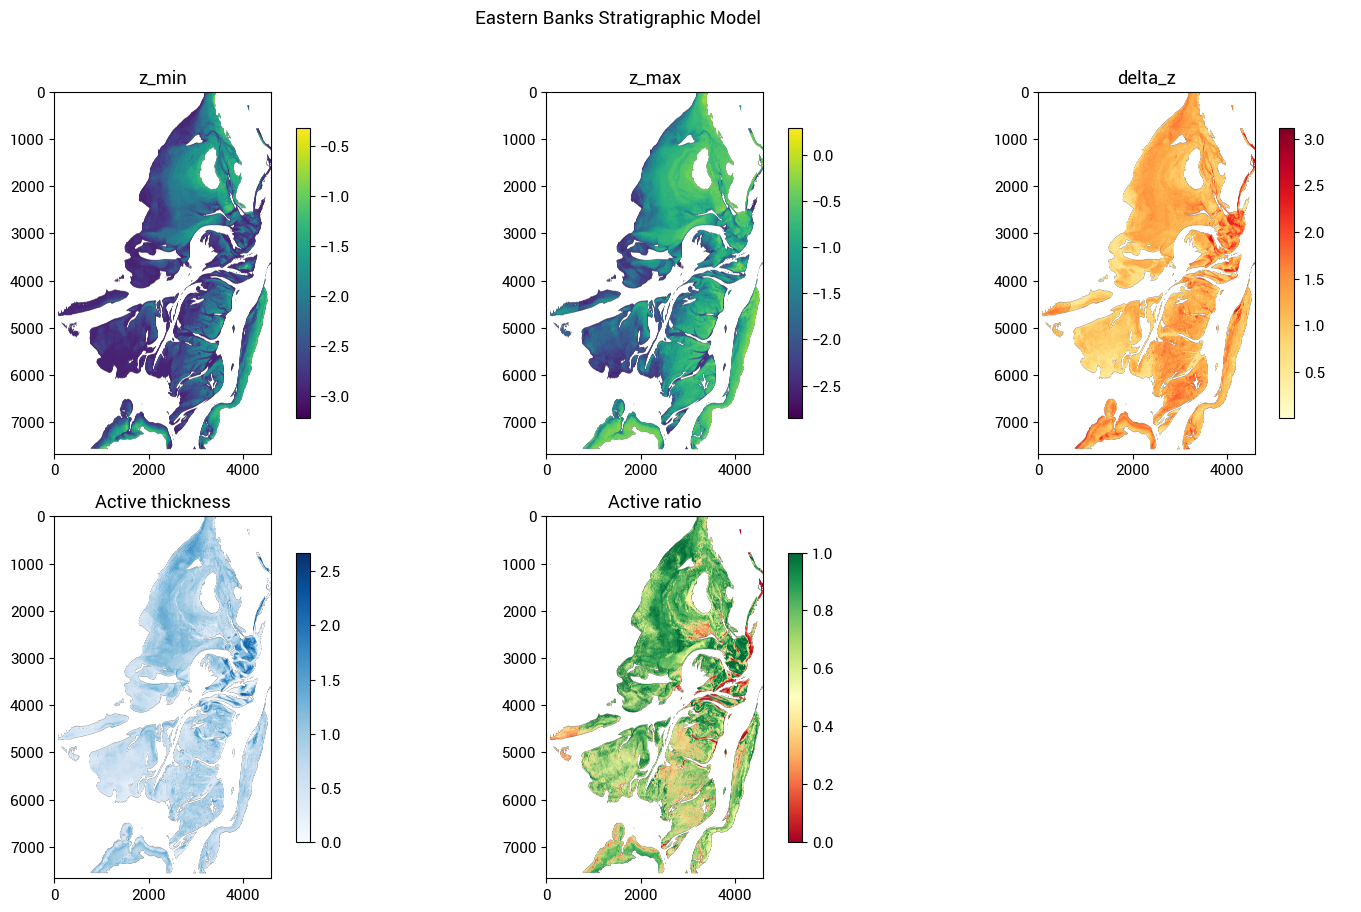

In [23]:
# ============================================================================
# Stratigraphic analysis / profiles (Pearson et al 2022)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

pixel_size_m = 3

n_t = stack_pred.shape[0]
final_year = years[-1]

# ----------------------------------------------------------------------------
# Stratigraphic core layers
# ----------------------------------------------------------------------------
z_min = np.nanmin(stack_pred, axis=0) # active layer floor
z_max = np.nanmax(stack_pred, axis=0) # ceiling
z_final = stack_pred[-1] # most recent surface

envelope = z_max - z_min # total range of morphodynamic change

# ----------------------------------------------------------------------------
# Active layer
# ----------------------------------------------------------------------------

# --- active = sediment between z_min and z_final ---
active = np.where(
    ~np.isnan(z_final) & ~np.isnan(z_min),
    z_final - z_min,
    np.nan
)

# --- active ratio: current surface occupies how much of total envelope ---
# 1.0 = at z_max (fully accreted), 0.0 = at z_min (fully eroded back to floor)
active_ratio = np.where(envelope > 0.01, active / envelope, np.nan)

# ----------------------------------------------------------------------------
# Deposite age
# ----------------------------------------------------------------------------
# most recent survey where elevation >= current surface

deposit_year = np.full((H, W), np.nan, dtype=np.float32)

for t, yr in enumerate(years[:-1]):
    mask = (
        ~np.isnan(stack_pred[t]) &
        ~np.isnan(z_final) &
        (stack_pred[t] >= z_final - 0.05)
    )
    deposit_year[mask] = yr

# Pixels never previously at current level = freshly deposited in final epoch
deposit_year = np.where(np.isnan(deposit_year), years[-1], deposit_year)
deposit_age = final_year - deposit_year

# ----------------------------------------------------------------------------
# Epoch split
# ----------------------------------------------------------------------------
stack_e1 = stack_pred[wv2_idx]
stack_e2 = stack_pred[sd8_idx]

z_min_e1 = np.nanmin(stack_e1, axis=0)
z_min_e2 = np.nanmin(stack_e2, axis=0)
z_final_e1 = stack_e1[-1]
z_final_e2 = stack_e2[-1]

active_e1 = np.where(~np.isnan(z_final_e1) & ~np.isnan(z_min_e1), z_final_e1 - z_min_e1, np.nan)
active_e2 = np.where(~np.isnan(z_final_e2) & ~np.isnan(z_min_e2), z_final_e2 - z_min_e2, np.nan)

# --- shift in active layer ---
# potive = z_min rose; passive layer accreted upward
floor_shift = z_min_e2 - z_min_e1

# --- add strat vars to df ---

strat_vars = {
    "active_ratio": active_ratio,
    "deposit_age":  deposit_age,
    "floor_shift":  floor_shift,
    "envelope":     envelope,
    "active_e1":    active_e1,
    "active_e2":    active_e2,
}

assert all(arr.shape == (H, W) for arr in strat_vars.values()), \
    "Shape mismatch — raster vars don't match (H, W)"
assert idx.max() < H * W, "idx out of bounds"

for name, arr in strat_vars.items():
    df[name] = arr.ravel()[idx]

# ============================================================================
# Per bank summ
# ============================================================================
bank_stats = []
for bank in df["bank"].dropna().unique():
    grp_idx = df[df["bank"] == bank]["idx"].values
    bank_stats.append({
        "bank": bank,
        "z_min_median":      np.nanmedian(z_min.ravel()[grp_idx]),
        "envelope_median":   np.nanmedian(envelope.ravel()[grp_idx]),
        "active_median":     np.nanmedian(active.ravel()[grp_idx]),
        "active_ratio_mean": np.nanmean(active_ratio.ravel()[grp_idx]),
        "deposit_age_median":np.nanmedian(deposit_age.ravel()[grp_idx]),
        "active_e1_median":  np.nanmedian(active_e1.ravel()[grp_idx]),
        "active_e2_median":  np.nanmedian(active_e2.ravel()[grp_idx]),
        "floor_shift_median":np.nanmedian(floor_shift.ravel()[grp_idx]),
        "V_envelope_m3":     np.nansum(envelope.ravel()[grp_idx]) * pixel_size_m**2,
        "V_active_m3":       np.nansum(active.ravel()[grp_idx])   * pixel_size_m**2,
        "bank_area_m2":      np.sum(~np.isnan(z_final.ravel()[grp_idx])) * pixel_size_m**2,
    })

bank_stats = pd.DataFrame(bank_stats).sort_values("active_median", ascending=False)
print(bank_stats.round(3).to_string(index=False))

# ============================================================================
# maps
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

titles = ["z_min", "z_max", "delta_z", "Active thickness", "Active ratio"]

arrays = [z_min, z_max, envelope, active, active_ratio]

cmaps  = ["viridis", "viridis", "YlOrRd", "Blues", "RdYlGn"]

for ax, arr, title, cmap in zip(axes.ravel(), arrays, titles, cmaps):
    im = ax.imshow(arr, cmap=cmap, origin="upper")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

axes.ravel()[-1].set_axis_off()

plt.suptitle("Eastern Banks Stratigraphic Model", y=1.01)
plt.tight_layout()
plt.show()

In [24]:
from scipy import stats
from itertools import combinations

strat_vars_to_test = [
    ("envelope",      "Morphodynamic Envelope Depth"),
    ("deposit_age",   "Deposit Age"),
    ("floor_shift",   "Floor Shift (Epoch 1 → 2)"),
    ("active_e1",     "Active Layer Thickness — Epoch 1"),
    ("active_e2",     "Active Layer Thickness — Epoch 2"),
    ("active_ratio",  "Active Ratio"),
]

for var_col, var_label in strat_vars_to_test:
    print(f"\n{'='*70}")
    print(f"  {var_label.upper()}")
    print(f"{'='*70}")

    grps = {b: g[var_col].dropna() for b, g in df.groupby("bank")}

    # --- descriptive stats ---
    stats_desc = pd.DataFrame({
        b: {
            "n":       len(v),
            "median":  v.median(),
            "q25":     v.quantile(.25),
            "q75":     v.quantile(.75),
            "pct_neg": (v < 0).mean(),
            "pct_pos": (v > 0).mean(),
        }
        for b, v in grps.items()
    }).T.round(3)

    # --- Kruskal-Wallis ---
    h, p_kw = stats.kruskal(*grps.values())
    n_total  = sum(len(v) for v in grps.values())
    eta2     = (h - len(grps) + 1) / (n_total - len(grps))
    kw_result = pd.DataFrame([{
        "variable": var_label,
        "H":        round(h,    3),
        "p":        round(p_kw, 4),
        "eta2":     round(eta2, 4),
    }]).set_index("variable")

    # --- pairwise Mann-Whitney U ---
    def _mwu(b1, b2):
        v1, v2 = grps[b1], grps[b2]
        stat, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
        r_rb    = round(1 - (2 * stat) / (len(v1) * len(v2)), 3)
        return {"bank_1": b1, "bank_2": b2,
                "p": round(p, 4), "r_rb": r_rb}

    mwu_result = pd.DataFrame([
        _mwu(b1, b2) for b1, b2 in combinations(grps, 2)
    ])

    mean_rrb = (
        mwu_result
        .melt(id_vars="r_rb",
              value_vars=["bank_1", "bank_2"],
              value_name="bank")
        .groupby("bank")["r_rb"]
        .mean()
        .sort_values(ascending=False)
        .rename("mean_r_rb")
        .to_frame()
        .round(3)
    )

    # --- Wilcoxon signed-rank vs zero (directional test) ---
    # only meaningful for floor_shift / signed variables
    if var_col in ("floor_shift", "active_ratio"):
        def _wilcoxon(bank, vals):
            try:
                stat, p = stats.wilcoxon(vals, alternative="greater")
                n = len(vals)
                r = round((2 * stat) / (n * (n + 1) / 2) - 1, 3)
                return {"bank": bank, "p": round(p, 4), "r": r}
            except ValueError:
                return {"bank": bank, "p": np.nan, "r": np.nan}

        wilcoxon_result = pd.DataFrame([
            _wilcoxon(b, v) for b, v in grps.items()
        ]).set_index("bank")
        display(wilcoxon_result)

    display(stats_desc)
    display(kw_result)
    display(mwu_result)
    display(mean_rrb)


  MORPHODYNAMIC ENVELOPE DEPTH


,n,median,q25,q75,pct_neg,pct_pos
amity,3168330.0,1.240,1.005,1.464,0.0,1.0
chain,327515.0,0.941,0.698,1.191,0.0,1.0
maroom,1704118.0,0.858,0.709,1.016,0.0,1.0
moreton,4961947.0,1.165,0.973,1.322,0.0,1.0
sth_pass,613368.0,1.405,1.040,1.772,0.0,1.0
wanga,605250.0,1.088,0.962,1.325,0.0,1.0


,H,p,eta2
variable,,,
Morphodynamic Envelope Depth,1690916.776,0.0,0.1486


,bank_1,bank_2,p,r_rb
0,amity,chain,0.0,-0.400
1,amity,maroom,0.0,-0.588
2,amity,moreton,0.0,-0.160
3,amity,sth_pass,0.0,0.220
4,amity,wanga,0.0,-0.158
5,chain,maroom,0.0,-0.147
6,chain,moreton,0.0,0.318
7,chain,sth_pass,0.0,0.518
8,chain,wanga,0.0,0.328
9,maroom,moreton,0.0,0.544


,mean_r_rb
bank,
sth_pass,0.283
maroom,0.205
moreton,0.202
chain,0.123
wanga,0.076
amity,-0.217


...

,p,r
bank,,
amity,0.0,0.948
chain,0.0,0.999
maroom,0.0,0.999
moreton,0.0,0.995
sth_pass,0.0,0.825
wanga,0.0,0.936


,n,median,q25,q75,pct_neg,pct_pos
amity,3168330.0,0.635,0.443,0.811,0.0,0.987
chain,327515.0,0.507,0.326,0.791,0.0,1.000
maroom,1704118.0,0.685,0.541,0.847,0.0,1.000
moreton,4961947.0,0.820,0.689,0.919,0.0,0.999
sth_pass,613368.0,0.759,0.274,0.997,0.0,0.955
wanga,605250.0,0.657,0.512,0.798,0.0,0.984


,H,p,eta2
variable,,,
Active Ratio,1149869.286,0.0,0.101


,bank_1,bank_2,p,r_rb
0,amity,chain,0.0,-0.147
1,amity,maroom,0.0,0.154
2,amity,moreton,0.0,0.402
3,amity,sth_pass,0.0,0.090
4,amity,wanga,0.0,0.033
5,chain,maroom,0.0,0.307
6,chain,moreton,0.0,0.470
7,chain,sth_pass,0.0,0.133
8,chain,wanga,0.0,0.178
9,maroom,moreton,0.0,0.288


,mean_r_rb
bank,
chain,0.188
maroom,0.124
moreton,0.122
amity,0.106
sth_pass,-0.004
wanga,-0.085


In [25]:
groups = {
    "(a)": ["sth_pass", "moreton"],
    "(b)": ["wanga", "amity", "maroom"],
}

def _auto_row(banks_in_group):
    rows = {b: set(df.loc[df["bank"] == b, "idx"].values // W)
            for b in banks_in_group}
    common = set.intersection(*rows.values())
    if common:
        return int(np.median(sorted(common)))
    return int(np.median([np.mean(sorted(r)) for r in rows.values()]))

for ax, (group_name, bank_grp) in zip(axes, groups.items()):
    row_idx = _auto_row(bank_grp)
    n_cross = sum(row_idx in set(df.loc[df["bank"] == b, "idx"].values // W)
                  for b in bank_grp)
    print(f"{group_name}: row {row_idx} ({n_cross}/{len(bank_grp)} banks crossed)")

(a): row 3143 (2/2 banks crossed)
(b): row 5169 (3/3 banks crossed)


In [27]:
def extract_transect(arr_3d, row=None, col=None):
    if row is not None:
        return arr_3d[:, row, :]
    return arr_3d[:, :, col]

In [28]:
# ============================================================================
# Stratigraphic profiles (transect cross-sections)
# ============================================================================

from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.collections import PolyCollection
import matplotlib.cm as cm
import matplotlib.patches as mpatches

def plot_strati(
    stack,
    years,
    row=None,
    col=None,
    pixel_size_m = 3.0,
    bin_m = None,
    ax=None,
    y_min = None,
    taper = True,
    n_taper = 1
    ):

    def _taper_edges(row, y_min, n_taper = n_taper):
        out = row.copy()
        valid = ~np.isnan(row)
        if not valid.any():
            return out

        edges  = np.diff(valid.astype(int))
        starts = np.where(edges == 1)[0] + 1
        ends = np.where(edges == -1)[0]

        if valid[0]:
            starts = np.concatenate([[0], starts])
        if valid[-1]:
            ends = np.concatenate([ends, [len(row) - 1]])

        for s in starts:
            for j in range(1, n_taper + 1):
                k = s - j
                if k >= 0 and np.isnan(out[k]):
                    out[k] = row[s] + (y_min - row[s]) * j / (n_taper + 1)

        for e in ends:
            for j in range(1, n_taper + 1):
                k = e + j
                if k < len(row) and np.isnan(out[k]):
                    out[k] = row[e] + (y_min - row[e]) * j / (n_taper + 1)
        return out
    
    def _plot_lines(arr, **kwargs):
        ax.plot(x, arr, **kwargs)
        floor = y_min if y_min is not None else z_lo
        valid = ~np.isnan(arr)
        if not valid.any():
            return
        edges = np.diff(valid.astype(int))
        starts = np.concatenate([([0] if valid[0] else []), np.where(edges == 1)[0] + 1])
        ends = np.concatenate([np.where(edges == -1)[0], ([len(arr)-1] if valid[-1] else [])])
        drop_kw = {k: v for k, v in kwargs.items() if k != "label"}
        for s in starts.astype(int):
            ax.plot([x[s], x[s]], [floor, arr[s]], **drop_kw)
        for e in ends.astype(int):
            ax.plot([x[e], x[e]], [floor, arr[e]], **drop_kw)

    # --- extract prof ---
    prof = extract_transect(stack, row=row, col=col)
    n_t, n_px = prof.shape
    x = np.arange(n_px) * pixel_size_m

    # --- bin aggreation ---
    if bin_m is not None:
        bin_px = max(1, int(round(bin_m / pixel_size_m)))
        n_bins = n_px // bin_px
        prof = np.array([
            np.nanmean(t[:n_bins * bin_px].reshape(n_bins, bin_px), axis=1)
            for t in prof
        ])
        x = (np.arange(n_bins) + 0.5) * bin_m

    if taper:
        taper_to = y_min
        prof = np.array([_taper_edges(prof[t], taper_to) for t in range(n_t)])
    
    n_t, n_px = prof.shape
    z_lo = np.nanmin(prof) - 0.5
    z_final  = prof[-1]
    z_max = np.nanmax(prof, axis=0)
    z_min = np.nanmin(prof, axis=0)

    # --- colour ---
    cmap = plt.get_cmap("copper")
    yr = np.array(years, dtype=float)
    yr_norm = (yr - yr[0]) / (yr[-1] - yr[0])

    passive_frac = 0.3
    colors = [cmap(passive_frac + (1 - passive_frac) * f) for f in yr_norm]
    passive_colour = cmap(0.1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 5))

    ax.set_facecolor("white")

    # --- fill; clipped to z_final; showing nothing above current surface ---
    for t in range(n_t - 1, -1, -1):
        z_top = np.minimum(prof[t], z_final)
        y = np.where((z_top < z_final) & ~np.isnan(z_top), z_top, np.nan)
        ax.fill_between(x, z_lo, z_top, color=colors[t], alpha=1.0, zorder = n_t - t)
        # year lines
        ax.plot(x, y, color="white", lw = 0.25, alpha=0.75, zorder=n_t - t + 0.5)

    # --- passive zone ---
    ax.fill_between(x, y_min, z_min, color = passive_colour, alpha = 0.75, zorder = 2*n_t, ec = "dimgrey", hatch = "/////")

    # --- current surface line ---
    _plot_lines(z_final, color="black", lw=0.5, zorder=2*n_t, label=str(years[-1]))

    # --- zmax, envelope line ---
    _plot_lines(z_max,   color="black", lw=0.5, ls=":", alpha=0.75, zorder=2*n_t+1, label="z_max (ceiling)")

    return ax

(a): 27.3790°S, 153.3501°E – 153.4317°E


C:\Users\samla\AppData\Local\Temp\ipykernel_35716\206463621.py:77: RuntimeWarning: Mean of empty slice
C:\Users\samla\AppData\Local\Temp\ipykernel_35716\206463621.py:89: RuntimeWarning: All-NaN slice encountered
C:\Users\samla\AppData\Local\Temp\ipykernel_35716\206463621.py:90: RuntimeWarning: All-NaN slice encountered


(b): 27.4340°S, 153.3150°E – 153.4330°E


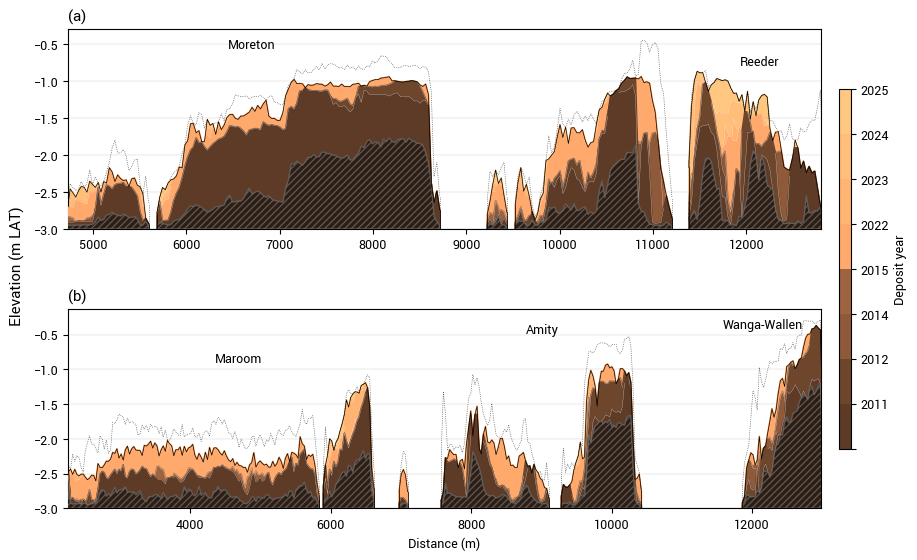

In [62]:
from pyproj import Transformer

cm = 1/2.54
plt.rcParams.update({"font.size": 9, "font.family": "Roboto"})
fig, axes = plt.subplots(2, 1, figsize=(29.7*cm, 15.8*cm), sharey=False, gridspec_kw={"hspace": 0.4})
y_min = -3.0
for ax, (group_name, bank_grp) in zip(axes, groups.items()):
    row_idx = _auto_row(bank_grp)
    row_pixels = df[df["row"] == row_idx]
    x_l = row_pixels["x"].min()
    x_r = row_pixels["x"].max()
    x_l_utm = row_pixels["x"].min()
    x_r_utm = row_pixels["x"].max()
    y_utm = row_pixels["y"].mean()
    bearing = (np.degrees(np.arctan2(x_r - x_l, 0)) + 360) % 360

    transformer = Transformer.from_crs("EPSG:32756", "EPSG:4326", always_xy=True)

    lon_l, lat = transformer.transform(x_l_utm, y_utm)
    lon_r, _   = transformer.transform(x_r_utm, y_utm)

    print(f"{group_name}: {abs(lat):.4f}°S, {lon_l:.4f}°E – {lon_r:.4f}°E")
    ax.set_title(f"{group_name}", loc="left")
    group_cols = np.unique(np.concatenate([
        df.loc[df["bank"] == b, "idx"].values % W
        for b in bank_grp if b in df["bank"].values
    ]))
    col_mask = np.ones(W, dtype=bool)
    col_mask[group_cols] = False
    stack_copy = stack_pred.copy()
    stack_copy[:, :, col_mask] = np.nan
    pixel_size_m = 3
    plot_strati(stack_copy, years, row=row_idx, pixel_size_m=pixel_size_m, bin_m=30, ax=ax, y_min=y_min)
    prof_row = stack_copy[:, row_idx, :]
    valid_cols = np.where(~np.all(np.isnan(prof_row), axis=0))[0]
    ax.set_xlim(valid_cols.min() * pixel_size_m, valid_cols.max() * pixel_size_m)
    ax.yaxis.grid(True, color="grey", lw=0.25, alpha=0.5, zorder=0)
    ax.set_ylim(y_min)
    ax.set_xlabel("Distance (m)" if ax is axes[-1] else "")
    ax.tick_params(axis="both")
    for bank in bank_grp:
        idx = df.loc[df["bank"] == bank, "idx"].values
        on_row = idx[(idx // W) == row_idx]
        cols = (on_row if len(on_row) > 0 else idx) % W
        span_mid = (cols.min() + cols.max()) / 2 * pixel_size_m
        bank_top = np.nanmax(stack_copy[:, row_idx, cols])
        y_offset = {"wanga": -0.15, "amity": -0.15}.get(bank, 0)
        x_offset = {"wanga": -250}.get(bank, 0)
        ax.text(span_mid + x_offset, bank_top + y_offset, BANK_LABELS[bank], ha="center", va="bottom", color="black")
cmap = plt.get_cmap("copper")
passive_frac = 0.3
yr = np.array(years, dtype=float)
yr_norm = (yr - yr[0]) / (yr[-1] - yr[0])
colors = [cmap(passive_frac + (1 - passive_frac) * f) for f in yr_norm]
disc_cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(len(years) + 1), ncolors=len(years))
sm = ScalarMappable(cmap=disc_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, location="right", shrink=0.75, aspect=30, pad=0.02)
cbar.set_ticks(np.arange(len(years) + 1))
cbar.set_ticklabels([""] + [str(y) for y in years])
cbar.set_label("Deposit year")
fig.supylabel("Elevation (m LAT)", x=0.075)
plt.savefig("../out/figs/strat_profiles.png", dpi=300, bbox_inches = "tight")
plt.show()

# Elev trend v. preds

In [ ]:
sg_percovs = sorted(
    [item for item in CATALOG.get_child("seagrass-percov").get_items()
     if INPUT_ASSETS["sg_percov"] in item.assets
     and item.datetime.year in years
     and item.datetime.month <= 8],
    key=lambda item: item.datetime
)

print(sg_percovs)

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling

idx = df["idx"].values
for item in sg_percovs:
    yr = item.datetime.year
    with rasterio.open(item.assets[INPUT_ASSETS["sg_percov"]].href) as src:
        arr = np.empty((H, W), dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=arr,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=crs,
            resampling=Resampling.nearest
        )
    df[f"sg_percov_{yr}"] = arr.ravel()[idx]

In [ ]:
df["mean_sg_density_e1"] = df[[f"sg_percov_{years[i]}" for i in wv2_idx]].median(axis=1)
df["mean_sg_density_e2"] = df[[f"sg_percov_{years[i]}" for i in sd8_idx]].median(axis=1)
df["mean_sg_density_all"] = df[[f"sg_percov_{years[i]}" for i in range(len(years)) if f"sg_percov_{years[i]}" in df.columns]].median(axis=1)

In [ ]:
from scipy.stats import spearmanr

rows = []
for bank, grp in df.groupby("bank"):
    for density_col, epoch_label in [("mean_sg_density_e1", "e1"), ("mean_sg_density_e2", "e2")]:
        for target in strat_vars:
            sub = grp[[density_col, target]].dropna()
            r, p = spearmanr(sub[density_col], sub[target])
            rows.append({"bank": bank, "epoch": epoch_label,
                         "target": target, "rho": round(r, 3), "p": round(p, 4)})


strat_sg = (pd.DataFrame(rows).pivot(index=["bank", "epoch"], columns="target", values="rho").round(3))
display(strat_sg)


seagrass vs strat_vars and elev trend not interpretable or meaningful across epochs

In [ ]:
from scipy.stats import spearmanr

rows = []
for bank, grp in df.groupby("bank"):
    sub = grp[["mean_sg_density_all", "delta_thresh"]].dropna()
    r, p = spearmanr(sub["mean_sg_density_all"], sub["delta_thresh"])
    rows.append({"bank": bank, "rho": round(r, 3), "p": round(p, 4), "n": len(sub)})

display(pd.DataFrame(rows).set_index("bank"))


seagrass vs elevation change is meaningful, 99.2% of significant pixels were positive. Seagrass shows strong associations with "less accretion" (i.e not erosion). As exposed areas accrete, seagrass are more likely to stay the same as density increases. Seagrass density vs elevation change is detectable at the decadal+ level, but not annual. Seagrass recovery isnt likely to detect morphodynamic changes except on this timeline

# Uncertainty

In [30]:
N_SAMPLES = 10_000

bank_mask = ~pd.isna(pd.Series(bank_raster.ravel()).map(bank_id_to_name))
valid_idx  = np.where(bank_mask)[0]

bank_lookup = (
    pd.DataFrame({
        "idx":  valid_idx,
        "bank": pd.Series(bank_raster.ravel()[valid_idx]).map(bank_id_to_name).values,
    })
    .dropna(subset=["bank"])
)

In [31]:
feat_stacks = sorted(
    [item for child in ("wv2-imagery", "sd8-imagery")
           for item in CATALOG.get_child(child).get_items()
           if INPUT_ASSETS["stack"] in item.assets],
    key=lambda item: item.datetime
)

path = feat_stacks[0].assets[INPUT_ASSETS["stack"]].href
print(pd.read_parquet(path, columns=None).columns.tolist())

predictors = ["pred", "std", "nd_B_R", "log_R", "nd_G_R", "nd_B_Y", "log_Y", "nd_G_Y"]
keep = ["idx"] + predictors

['B', 'G', 'Y', 'R', 'sg_percov', 'sg_species', 'sensor', 'tide_h', 'a_B', 'a_G', 'a_R', 'Kd_G', 'zSD', 'log_B', 'log_G', 'log_Y', 'log_R', 'nd_B_G', 'nd_B_Y', 'nd_B_R', 'nd_G_Y', 'nd_G_R', 'nd_Y_R', 'idx', 'pred', 'std', 'img_id', 'date']


In [32]:
N_SAMPLES = 10_000

stack_dfs = []
for item in feat_stacks:
    path  = item.assets[INPUT_ASSETS["stack"]].href
    df_s  = pd.read_parquet(path, columns=keep)
    df_s["year"]  = item.datetime.year
    df_s["epoch"] = "e1" if "wv2-imagery" in item.collection_id else "e2"
    df_s = df_s[df_s["idx"].isin(valid_idx)]
    df_s = df_s.replace([np.inf, -np.inf], np.nan).dropna(subset=keep)
    df_s = (
        df_s
        .merge(bank_lookup, on="idx", how="inner")
        .groupby("bank", group_keys=False)
        .apply(lambda g: g.sample(n=min(N_SAMPLES, len(g)), random_state=42))
        .reset_index(drop=True)
    )
    stack_dfs.append(df_s)

stack_df = pd.concat(stack_dfs, ignore_index=True)
stack_df = stack_df.rename(columns={"std": "pred_int"})

C:\Users\samla\AppData\Local\Temp\ipykernel_35716\2200853242.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
C:\Users\samla\AppData\Local\Temp\ipykernel_35716\2200853242.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
C:\Users\samla\AppData\Local\Temp\ipykernel_35716\2200853242.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 

In [33]:
print(stack_df.columns.tolist())

['idx', 'pred', 'pred_int', 'nd_B_R', 'log_R', 'nd_G_R', 'nd_B_Y', 'log_Y', 'nd_G_Y', 'year', 'epoch', 'bank']


In [34]:
# ============================================================================
# pred_int distribution by bank and epoch
# ============================================================================

from scipy import stats
from itertools import combinations

print("\n=== PRED INT BY BANK AND EPOCH ===")

for epoch in ["e1", "e2"]:
    print(f"\n--- {epoch.upper()} ---")
    epoch_sub = stack_df[stack_df["epoch"] == epoch]
    grps      = {b: g["pred_int"].values for b, g in epoch_sub.groupby("bank")}

    desc = pd.DataFrame({
        b: {
            "n":      len(v),
            "median": np.nanmedian(v),
            "q25":    np.nanpercentile(v, 25),
            "q75":    np.nanpercentile(v, 75),
            "mean":   np.nanmean(v),
        }
        for b, v in grps.items()
    }).T.round(4)
    display(desc)

    h, p_kw = stats.kruskal(*grps.values())
    n_total = sum(len(v) for v in grps.values())
    eta2    = (h - len(grps) + 1) / (n_total - len(grps))
    print(f"Kruskal-Wallis H={h:.3f}, p={p_kw:.4f}, eta2={eta2:.4f}")

    def _mwu(b1, b2):
        v1, v2 = grps[b1], grps[b2]
        st, p  = stats.mannwhitneyu(v1, v2, alternative="two-sided")
        r_rb   = round(1 - (2 * st) / (len(v1) * len(v2)), 3)
        return {"bank_1": b1, "bank_2": b2, "p": round(p, 4), "r_rb": r_rb}

    mwu = pd.DataFrame([_mwu(b1, b2) for b1, b2 in combinations(grps, 2)])
    mean_rrb = (
        mwu
        .melt(id_vars="r_rb", value_vars=["bank_1", "bank_2"], value_name="bank")
        .groupby("bank")["r_rb"].mean()
        .sort_values(ascending=False)
        .rename("mean_r_rb")
        .to_frame()
        .round(3)
    )
    display(mwu)
    display(mean_rrb)


=== PRED INT BY BANK AND EPOCH ===

--- E1 ---


,n,median,q25,q75,mean
amity,40000.0,0.4326,0.2850,0.5499,0.4473
chain,40000.0,0.2765,0.2110,0.3662,0.3121
maroom,40000.0,0.3515,0.2621,0.4625,0.3752
moreton,40000.0,0.4008,0.2596,0.5491,0.4274
sth_pass,40000.0,0.3453,0.2112,0.5544,0.4548
wanga,40000.0,0.5191,0.3751,0.6623,0.5423


Kruskal-Wallis H=26436.476, p=0.0000, eta2=0.1101


,bank_1,bank_2,p,r_rb
0,amity,chain,0.0000,-0.420
1,amity,maroom,0.0000,-0.192
2,amity,moreton,0.0000,-0.051
3,amity,sth_pass,0.0000,-0.128
4,amity,wanga,0.0000,0.256
5,chain,maroom,0.0000,0.304
6,chain,moreton,0.0000,0.346
7,chain,sth_pass,0.0000,0.203
8,chain,wanga,0.0000,0.619
9,maroom,moreton,0.0000,0.120


,mean_r_rb
bank,
wanga,0.385
chain,0.210
maroom,0.134
moreton,0.125
sth_pass,0.062
amity,-0.107



--- E2 ---


,n,median,q25,q75,mean
amity,40000.0,0.7325,0.4956,1.0190,0.7590
chain,40000.0,0.6011,0.4863,0.6914,0.5952
maroom,40000.0,0.6987,0.5684,0.8358,0.7068
moreton,40000.0,0.4991,0.3441,0.6562,0.5189
sth_pass,40000.0,0.5429,0.4009,0.6808,0.5641
wanga,40000.0,0.4647,0.3198,0.7755,0.5718


Kruskal-Wallis H=25361.997, p=0.0000, eta2=0.1057


,bank_1,bank_2,p,r_rb
0,amity,chain,0.0000,-0.289
1,amity,maroom,0.0000,-0.076
2,amity,moreton,0.0000,-0.426
3,amity,sth_pass,0.0000,-0.355
4,amity,wanga,0.0000,-0.337
5,chain,maroom,0.0000,0.331
6,chain,moreton,0.0000,-0.262
7,chain,sth_pass,0.0000,-0.153
8,chain,wanga,0.0000,-0.211
9,maroom,moreton,0.0000,-0.479


,mean_r_rb
bank,
chain,-0.117
sth_pass,-0.178
wanga,-0.197
maroom,-0.198
moreton,-0.208
amity,-0.297


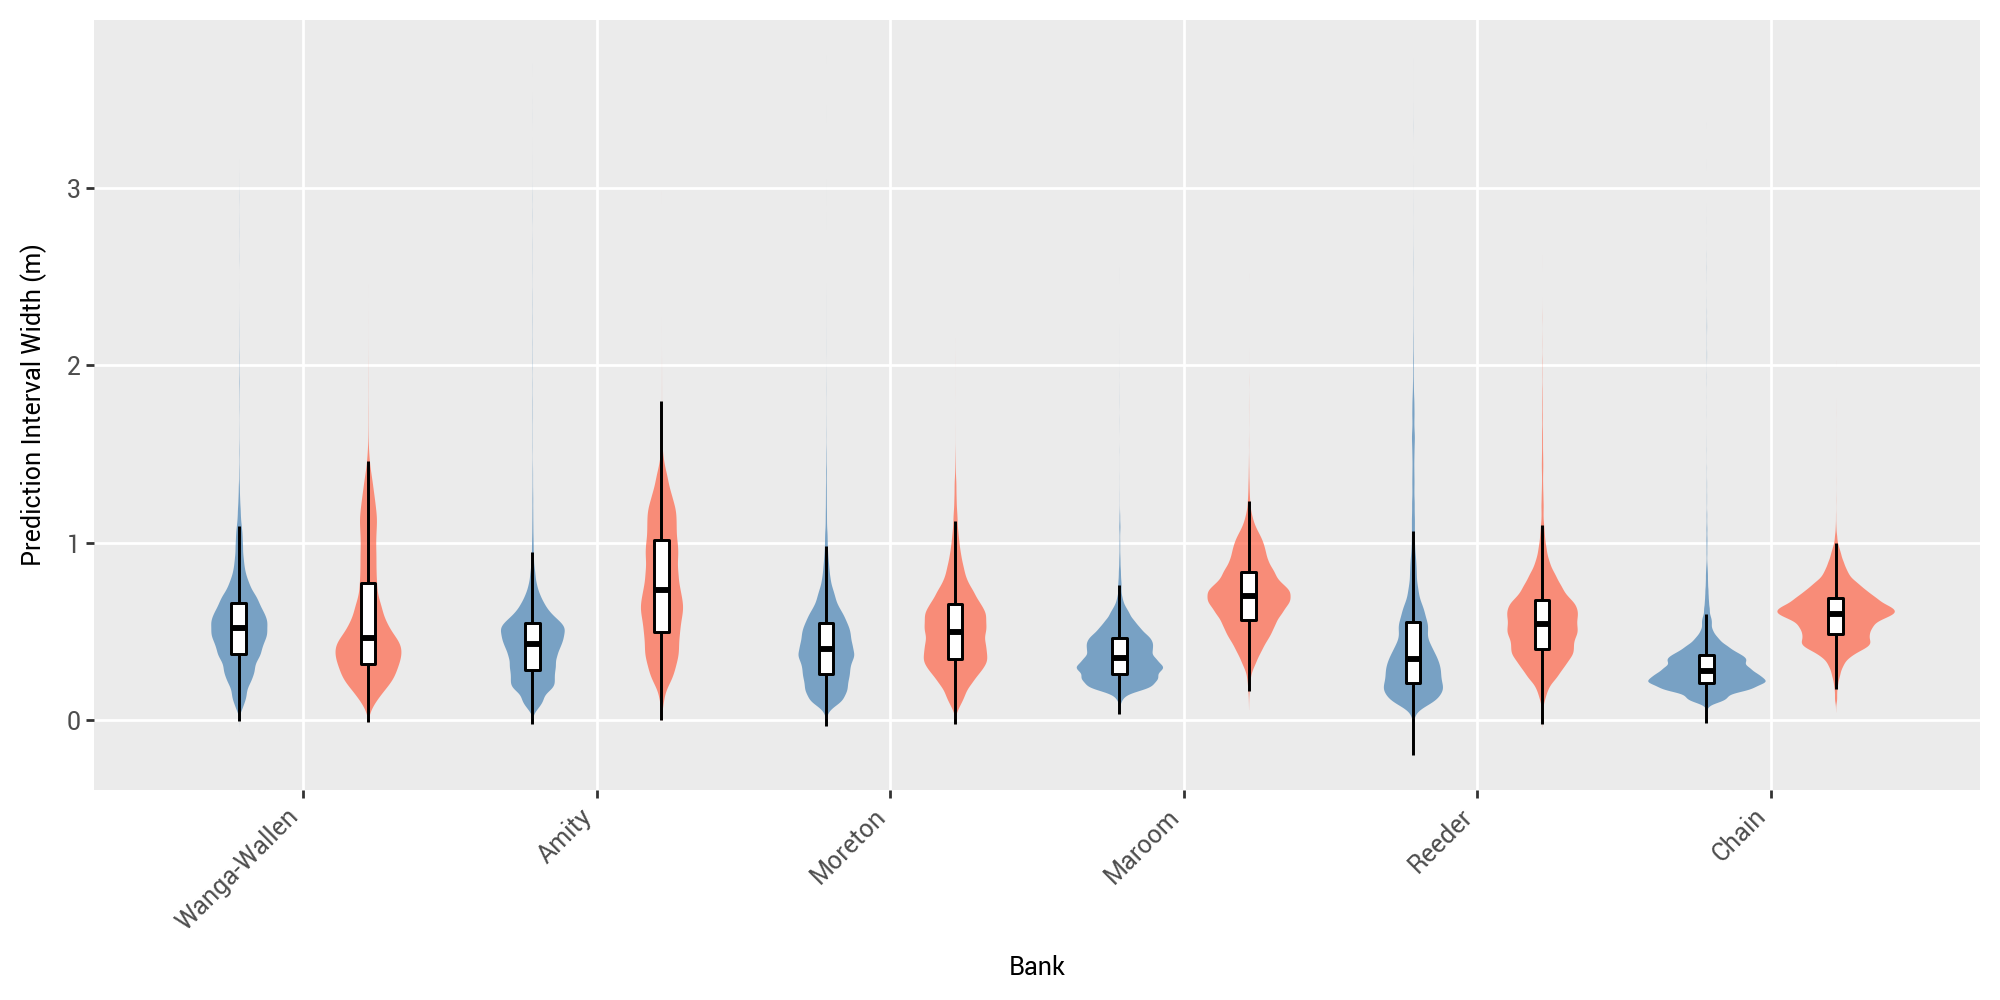

In [35]:
plot_df = stack_df[["bank", "epoch", "pred_int"]].dropna().copy()
plot_df["epoch_label"] = plot_df["epoch"].map({"e1": "Epoch 1", "e2": "Epoch 2"})

bank_order = (
    stack_df[stack_df["epoch"] == "e1"]
    .groupby("bank")["pred_int"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
plot_df["bank"] = pd.Categorical(plot_df["bank"], categories=bank_order, ordered=True)

COLORS = {"Epoch 1": "steelblue", "Epoch 2": "tomato"}
OFFSETS = {"Epoch 1": -0.22, "Epoch 2": 0.22}  # manual dodge offset

# Convert bank category to numeric, then shift by epoch offset
plot_df["x_num"] = plot_df["bank"].cat.codes.astype(float)
plot_df["x_dodge"] = plot_df["x_num"] + plot_df["epoch_label"].map(OFFSETS)

layers = []
for epoch_label, color in COLORS.items():
    edf = plot_df[plot_df["epoch_label"] == epoch_label].copy()

    layers += [
        geom_violin(
            aes(x="x_dodge", y="pred_int", group="x_dodge"),
            data=edf,
            fill=color,
            color="none",
            alpha=0.7,
            trim=True,
            width=0.4,
        ),
        geom_boxplot(
            aes(x="x_dodge", y="pred_int", group="x_dodge"),
            data=edf,
            fill="white",
            color="black",
            width=0.05,
            outlier_alpha=0,
            size=0.6,
        ),
    ]

# Dummy df for legend
legend_df = pd.DataFrame({
    "x_dodge": [0.0, 0.0],
    "epoch_label": ["Epoch 1", "Epoch 2"],
    "pred_int": [np.nan, np.nan],
})

bank_codes = list(range(len(bank_order)))

p = ggplot(legend_df, aes(x="x_dodge", y="pred_int", fill="epoch_label"))
for layer in layers:
    p = p + layer

(
    p
    + scale_fill_manual(values=COLORS, name="")
    + scale_x_continuous(
        breaks=bank_codes,
        labels=[BANK_LABELS[b] for b in bank_order],
    )
    + labs(
        x="Bank",
        y="Prediction Interval Width (m)",
    )
    + theme(
        text=element_text(size=9, family="Roboto"),
        plot_title=element_text(size=12, family="Roboto"),
        axis_text_x=element_text(rotation=45, hjust=1),
        figure_size=(10, 5),
        legend_position="bottom",
        panel_grid_minor=element_blank(),
    )
)

In [36]:
predictors_clean = ["pred", "nd_B_R", "log_R", "nd_G_R", "nd_B_Y", "log_Y", "nd_G_Y"]

In [43]:
from scipy.stats import spearmanr
import numpy as np

spear_rows = []
for epoch in ["e1", "e2"]:
    epoch_sub = stack_df[stack_df["epoch"] == epoch].dropna(
        subset=["pred_int"] + predictors_clean
    )
    for bank, grp in epoch_sub.groupby("bank"):
        for feat in predictors_clean:
            rho, p = spearmanr(grp[feat], grp["pred_int"])
            spear_rows.append({
                "epoch":   epoch,
                "bank":    bank,
                "feature": feat,
                "rho":     round(rho, 3),
                "p":       round(p, 4),
            })

spear_df = pd.DataFrame(spear_rows)
with pd.option_context('display.max_rows', None):
    display(spear_df)

,epoch,bank,feature,rho,p
0,e1,amity,pred,0.097,0.0000
1,e1,amity,nd_B_R,0.044,0.0000
2,e1,amity,log_R,-0.274,0.0000
3,e1,amity,nd_G_R,0.007,0.1433
4,e1,amity,nd_B_Y,-0.149,0.0000
5,e1,amity,log_Y,-0.297,0.0000
6,e1,amity,nd_G_Y,-0.254,0.0000
7,e1,chain,pred,0.661,0.0000
8,e1,chain,nd_B_R,-0.166,0.0000
9,e1,chain,log_R,0.282,0.0000


In [41]:
from sklearn.feature_selection import mutual_info_regression
import numpy as np

mi_rows = []
for epoch in ["e1", "e2"]:
    epoch_sub = stack_df[stack_df["epoch"] == epoch].dropna(
        subset=["pred_int"] + predictors_clean
    )
    for bank, grp in epoch_sub.groupby("bank"):
        X = grp[predictors_clean].values.astype(float)
        y = grp["pred_int"].values.astype(float)
        mi = mutual_info_regression(X, y, random_state=42)
        mi_total = mi.sum()
        for feat, score in zip(predictors_clean, mi):
            mi_rows.append({
                "epoch":   epoch,
                "bank":    bank,
                "feature": feat,
                "MI":      round(score, 4),
                "MI_norm": round(score / mi_total, 4) if mi_total > 0 else 0,
            })

mi_df = pd.DataFrame(mi_rows)
with pd.option_context('display.max_rows', None):
    display(mi_df)

,epoch,bank,feature,MI,MI_norm
0,e1,amity,pred,0.4673,0.2047
1,e1,amity,nd_B_R,0.3805,0.1667
2,e1,amity,log_R,0.3351,0.1468
3,e1,amity,nd_G_R,0.3549,0.1555
4,e1,amity,nd_B_Y,0.2293,0.1005
5,e1,amity,log_Y,0.2915,0.1277
6,e1,amity,nd_G_Y,0.2240,0.0981
7,e1,chain,pred,0.5642,0.2315
8,e1,chain,nd_B_R,0.2840,0.1165
9,e1,chain,log_R,0.4209,0.1727


In [48]:
import numpy as np
from plotnine import *
import pandas as pd

features_ordered = mi_df["feature"].unique().tolist()
n_features = len(features_ordered)

# --- angles: start at top (π/2 offset), go clockwise ---
angles = [np.pi/2 - 2*np.pi*i/n_features for i in range(n_features)]
angles_closed = angles + angles[:1]

# --- build radar data ---
radar_rows = []
for epoch in ["e1", "e2"]:
    for bank in mi_df["bank"].unique():
        sub = mi_df[
            (mi_df["epoch"] == epoch) &
            (mi_df["bank"] == bank)
        ].set_index("feature")["MI"]
        
        values = [sub.get(f, 0) for f in features_ordered]
        values_closed = values + values[:1]
        
        for angle, value, feature in zip(
            angles_closed,
            values_closed,
            features_ordered + [features_ordered[0]]
        ):
            radar_rows.append({
                "epoch":       epoch,
                "epoch_label": "Epoch 1" if epoch == "e1" else "Epoch 2",
                "bank":        bank,
                "feature":     feature,
                "angle":       angle,
                "MI":          value,
                "x":           value * np.cos(angle),
                "y":           value * np.sin(angle),
            })

radar_df = pd.DataFrame(radar_rows)

# --- feature label positions — pushed out to 1.15 ---
label_df = pd.DataFrame({
    "feature": features_ordered,
    "angle":   angles,
    "x":       [1.15 * np.cos(a) for a in angles],
    "y":       [1.15 * np.sin(a) for a in angles],
})

# --- reference circles ---
circle_df_rows = []
for r in [0.2, 0.4, 0.6, 0.8]:
    theta = np.linspace(0, 2 * np.pi, 100)
    for t in theta:
        circle_df_rows.append({"x": r * np.cos(t), "y": r * np.sin(t), "r": r})
circle_df = pd.DataFrame(circle_df_rows)

# --- spoke lines ---
spoke_df = pd.DataFrame({
    "x":    [np.cos(a) for a in angles],
    "y":    [np.sin(a) for a in angles],
    "xend": [0] * n_features,
    "yend": [0] * n_features,
})

bank_order = (
    mi_df.groupby("bank")["MI"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

radar_df["bank"] = radar_df["bank"].map(BANK_LABELS)
bank_order_labels = sorted([BANK_LABELS[b] for b in bank_order])
radar_df["bank"] = pd.Categorical(radar_df["bank"], categories=bank_order_labels, ordered=True)
label_df["feature"] = label_df["feature"].map(FEATURE_LABELS)

p = (
    ggplot()
    + geom_path(
        circle_df,
        aes(x="x", y="y", group="r"),
        color="grey", size=0.3, linetype="dashed"
    )
    + geom_segment(
        spoke_df,
        aes(x="xend", y="yend", xend="x", yend="y"),
        color="grey", size=0.3
    )
    + geom_polygon(
        radar_df,
        aes(x="x", y="y", color="epoch_label", fill="epoch_label", group="epoch_label"),
        alpha=0.2, size=0.8
    )
    + geom_text(
        label_df,
        aes(x="x", y="y", label="feature"),
        size=4, color="black"
    )
    + geom_text(
        pd.DataFrame({"x": [0.2, 0.4, 0.6, 0.8], "y": [0] * 4, "r": [0.2, 0.4, 0.6, 0.8]}),
        aes(x="x", y="y", label="r"),
        size=4, color="grey", va="bottom", nudge_x = 0.075
    )
    + scale_color_manual(
        values={"Epoch 1": "steelblue", "Epoch 2": "tomato"},
        name=""
    )
    + scale_fill_manual(
        values={"Epoch 1": "steelblue", "Epoch 2": "tomato"},
        name=""
    )
    + facet_wrap("bank", ncol=3)
    + coord_equal()
    + theme_void()
    + labs(fill = "", color= "")
    + theme_void()
    + theme(
        figure_size=(15.92*cm, 12*cm),
        strip_text=element_text(size=7, family="Roboto"),
        legend_text=element_text(size=7, family="Roboto"),
        legend_title=element_text(size=7, family="Roboto"),
        legend_position="bottom",
    )
)

p.save("../out/figs/mi_radar.png", dpi=300, bbox_inches="tight")

c:\Users\samla\.conda\envs\geospat\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.26771653543307 x 4.724409448818897 in image.
c:\Users\samla\.conda\envs\geospat\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: ../out/figs/mi_radar.png


In [39]:
import statsmodels.formula.api as smf

# bin pred into depth intervals
stack_df["pred_bin"] = pd.cut(stack_df["pred"], bins=20)

# --- fit quantile regression per bank per epoch ---
qr_coef_rows = []
for epoch in ["e1", "e2"]:
    for bank in stack_df["bank"].unique():
        sub = stack_df[
            (stack_df["epoch"] == epoch) &
            (stack_df["bank"] == bank)
        ].dropna(subset=["pred", "pred_int"])
        
        for q in [0.1, 0.5, 0.9]:
            try:
                model  = smf.quantreg("pred_int ~ pred + I(pred**2)", sub)
                result = model.fit(q=q, max_iter=1000)
                qr_coef_rows.append({
                    "epoch":     epoch,
                    "bank":      bank,
                    "quantile":  q,
                    "intercept": round(result.params["Intercept"],   4),
                    "pred":      round(result.params["pred"],         4),
                    "pred_sq":   round(result.params["I(pred ** 2)"], 4),
                    "pseudo_r2": round(result.prsquared,              4),
                })
            except Exception as e:
                print(f"Failed: {epoch} {bank} q={q} — {e}")

qr_coef_df = pd.DataFrame(qr_coef_rows)

pd.set_option("display.max_rows", None)
display(qr_coef_df.round(4))

,epoch,bank,quantile,intercept,pred,pred_sq,pseudo_r2
0,e1,amity,0.1,-1.2946,-1.4498,-0.3230,0.1848
1,e1,amity,0.5,-1.0967,-1.5564,-0.3733,0.1629
2,e1,amity,0.9,-0.0963,-0.9432,-0.2584,0.0411
3,e1,chain,0.1,-3.0584,-2.8341,-0.5941,0.2187
4,e1,chain,0.5,-2.3231,-2.4437,-0.5389,0.2328
5,e1,chain,0.9,-2.8815,-3.4424,-0.8068,0.2602
6,e1,maroom,0.1,-2.3830,-2.3890,-0.5173,0.2872
7,e1,maroom,0.5,-2.0533,-2.3454,-0.5343,0.3338
8,e1,maroom,0.9,-1.1545,-1.8570,-0.4612,0.2041
9,e1,moreton,0.1,-0.0227,-0.1823,-0.0415,0.0071


In [64]:
preds = sorted(
    [item for child in ("wv2-imagery", "sd8-imagery")
           for item in CATALOG.get_child(child).get_items()
           if INPUT_ASSETS["pred"] in item.assets],
    key=lambda item: item.datetime
)

preds_ints = sorted(
    [item for child in ("wv2-imagery", "sd8-imagery")
           for item in CATALOG.get_child(child).get_items()
           if INPUT_ASSETS["pred_int"] in item.assets],
    key=lambda item: item.datetime
)

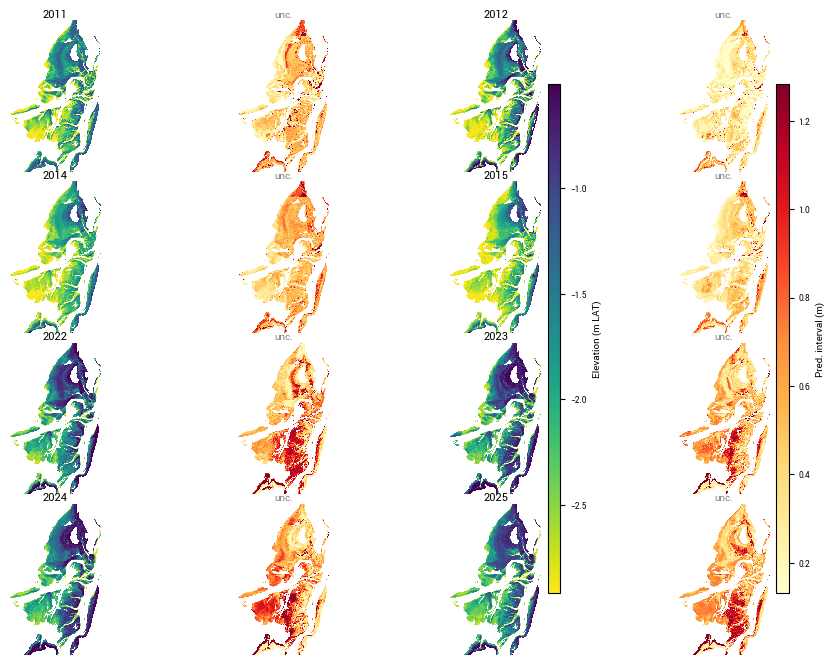

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

cm = 1 / 2.54

SCALE = 0.25

bathy_col = CATALOG.get_child("bathymetry")
with rasterio.open(bathy_col.assets["bathy-coverage"].href) as src:
    bank_mask = src.read(1).astype(bool)

# get exact output shape from first raster
with rasterio.open(preds[0].assets[INPUT_ASSETS["pred"]].href) as src:
    h_rs = int(src.height * SCALE)
    w_rs = int(src.width  * SCALE)

from scipy.ndimage import zoom
bank_mask_rs = zoom(
    bank_mask.astype(np.float32),
    (h_rs / bank_mask.shape[0], w_rs / bank_mask.shape[1]),
    order=0
) > 0.5

rmin, rmax = np.where(np.any(bank_mask_rs, axis=1))[0][[0, -1]]
cmin, cmax = np.where(np.any(bank_mask_rs, axis=0))[0][[0, -1]]

def load_crop(item, key):
    with rasterio.open(item.assets[key].href) as src:
        arr = src.read(
            1,
            out_shape=(h_rs, w_rs),
            resampling=rasterio.enums.Resampling.average
        ).astype(np.float32)
        arr[arr == src.nodata] = np.nan
    arr[~bank_mask_rs] = np.nan
    return arr[rmin:rmax+1, cmin:cmax+1]

# --- load ---
preds_arr, ints_arr, titles = [], [], []
for p, pi in zip(preds, preds_ints):
    preds_arr.append(load_crop(p, INPUT_ASSETS["pred"]))
    ints_arr.append(load_crop(pi, INPUT_ASSETS["pred_int"]))
    titles.append(p.datetime.strftime("%Y"))

# --- common scales ---
p_vmin, p_vmax = np.nanpercentile(np.concatenate([a[np.isfinite(a)] for a in preds_arr]), [2, 98])
i_vmin, i_vmax = np.nanpercentile(np.concatenate([a[np.isfinite(a)] for a in ints_arr]), [2, 98])

# --- 4 rows x 4 cols: (pred | int) x 2 per row ---
fig, axes = plt.subplots(4, 4, figsize=(29.7 * cm, 21.0 * cm),
                          gridspec_kw={"hspace": 0.05, "wspace": 0.03})

im_p = im_i = None
for i, (pa, ia, title) in enumerate(zip(preds_arr, ints_arr, titles)):
    row, col = i // 2, (i % 2) * 2
    ax_p, ax_i = axes[row, col], axes[row, col + 1]
    im_p = ax_p.imshow(pa, cmap="viridis_r", vmin=p_vmin, vmax=p_vmax, interpolation="none")
    im_i = ax_i.imshow(ia, cmap="YlOrRd",    vmin=i_vmin, vmax=i_vmax, interpolation="none")
    ax_p.set_title(title, fontsize=8, pad=2)
    ax_i.set_title("unc.", fontsize=7, pad=2, color="grey")
    ax_p.axis("off")
    ax_i.axis("off")

cbar_p = fig.colorbar(im_p, ax=axes[:, [0, 2]], fraction=0.025, pad=0.01, aspect=40, shrink=0.8)
cbar_p.set_label("Elevation (m LAT)", fontsize=7)
cbar_p.ax.tick_params(labelsize=6)

cbar_i = fig.colorbar(im_i, ax=axes[:, [1, 3]], fraction=0.025, pad=0.01, aspect=40, shrink=0.8)
cbar_i.set_label("Pred. interval (m)", fontsize=7)
cbar_i.ax.tick_params(labelsize=6)

plt.savefig("../out/figs/raw_preds_a4.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
